In [123]:
import numpy as np
import pandas as pd
from PIL import Image
from wordcloud import WordCloud      # for creating wordcloud
import matplotlib.pyplot as plt      # for plotting
from nltk.corpus import stopwords    # for removing stopwords
import requests                      # for making a request to a web page
from bs4 import BeautifulSoup        # for processing text from a website; not necessary if using own text

In [125]:
# importing dataset with pandas
df = pd.read_csv('Downloads/review - review.csv', header=0, index_col=False)

In [126]:
df

,5,3,Thinking about taking this class because you think it's going to be an easy science req class? Expect to memorize tons and tons of crap that you will quickly forget. Very boring subject matter.,Unnamed: 3,"museum project, midterm, final.",2,2000-01-01 0:00:00
0,6,4,D'Altroy has the skill of taking an interestin...,NaN,Midterm & Final Exams.,2.0,2000-01-01 0:00:00
1,7,4,Terry D'Altroy is not really a bad professor. ...,NaN,NaN,3.0,2000-01-01 0:00:00
2,8,5,Since 'Anthrop' does end in 'ology' this class...,NaN,Midterm & Final Exams; 3 quizzes; no essays.,3.0,2000-01-01 0:00:00
3,9,5,This monkey class is so awful. Be prepared to ...,NaN,"quizzes, midterm, final.",1.0,2000-01-01 0:00:00
4,13,7,"Intelligent, focused and well-dressed. As an i...",NaN,Midterm and Final exams.,4.0,2000-01-01 0:00:00
...,...,...,...,...,...,...,...
28365,85570,776,ContentOne,NaN,ContentTwo,5.0,2025-02-26 12:02:39
28366,85571,776,ContentOne,NaN,ContentTwo,5.0,2025-02-26 12:02:39
28367,85572,776,ContentOne,NaN,ContentTwo,5.0,2025-02-26 12:02:39
28368,85573,776,ContentOne,NaN,ContentTwo,5.0,2025-02-26 12:02:40


In [129]:
# need to do the following data processing: -truncate years to exclude months, -redo ID sections

In [131]:
# data pre-processing

# adding in dummy headers for now so we don't shift down the rows of our dataset
headers = ['A', 'B', 'C', 'D', 'E', 'F', 'G']

df.columns = headers

# only keep the third column and seventh column - review + date
df1 = df.iloc[:, [2,6]]

df1

print(df1.columns)

Index(['C', 'G'], dtype='object')


# converting our G column (date) to a DateTime object
df1['G'] = pd.to_datetime(df1['G'])

# creating a boolean mask so we know what rows to remove
remove = ~(df1['G'].dt.year == 2000)

first_impression = df1[remove]

# here, you can filter by the year:
averages = np.array([])

for year in range(2001, 2026):
    first_impression = df1[df1['G'].dt.year == year] # change the year in here so you can filter by whatever year you want

# print(first_impression['C'].str.len()) # prints out the length of each review in each entry of 'C' for 2001
    first_impression['Average Word Count'] = first_impression['C'].str.len().mean()
# print(average_tokens)

# convert first_impression to list
first_impression = first_impression['C'].to_list()

# convert first_impression to text
text = ' '.join(str(item) for item in first_impression if pd.notna(item))

plt.figure(figsize=(10, 6))

for year, group_data in first_impression.groupby('G'):
    plt.hist(group_data['Average Word Count'], bins=15, alpha=0.5, label=str(year))

plt.xlabel('Year')
plt.ylabel('Word count')
plt.title('Average word count in all reviews from 2001-2025')
plt.show()


C:\Users\emiik\AppData\Local\Temp\ipykernel_35540\295137283.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1["G"] = pd.to_datetime(df1["G"], errors="coerce")


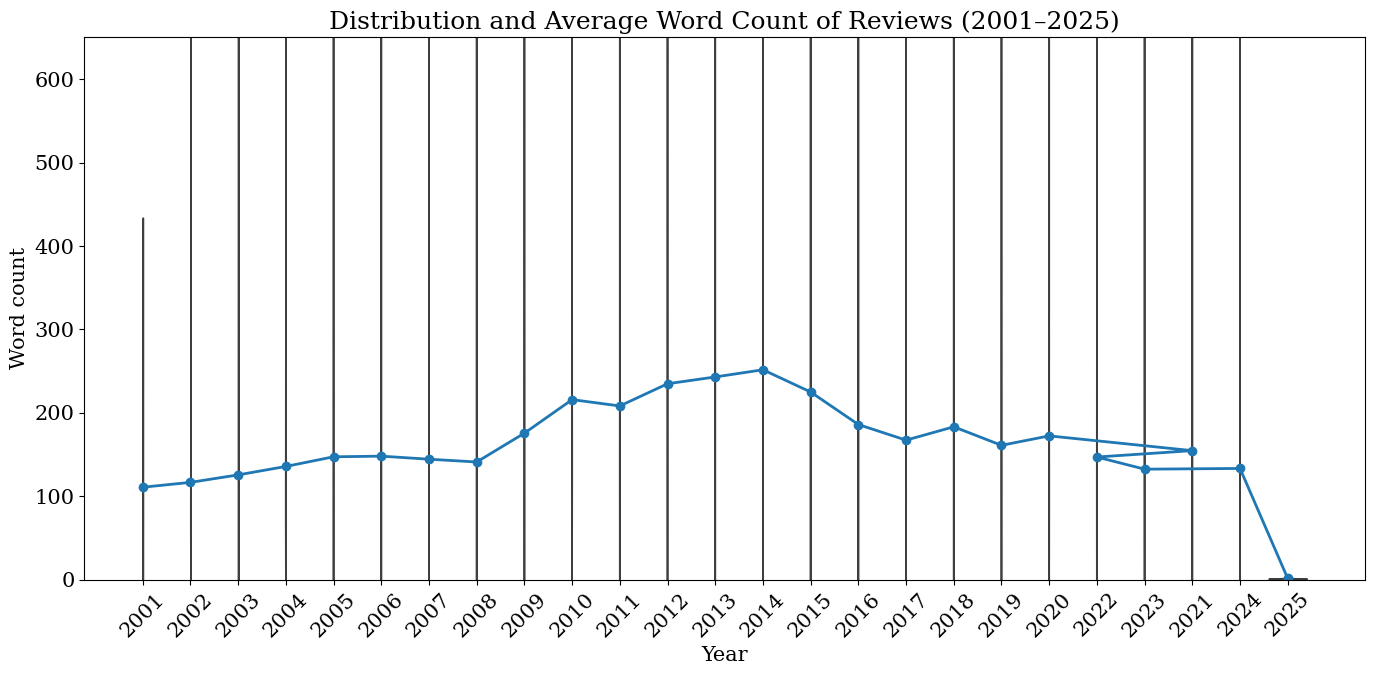

In [134]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# convert date column to datetime to parse for the year easier
df1["G"] = pd.to_datetime(df1["G"], errors="coerce")

# remove the 2000s and copy it
df = df1[df1["G"].dt.year != 2000].copy()

# extract the year from the G column
df["year"] = df["G"].dt.year

# compute by WORDS, not character count
df["word_count"] = df["C"].astype(str).str.split().str.len()

# 2001 to 2025 only
df = df[df["year"].between(2001, 2025)]

# compute average word count per year
avg_by_year = df.groupby("year", as_index=False)["word_count"].mean()


# Ensure year is treated as CATEGORY for both plots
df["year_str"] = df["year"].astype(str)
avg_by_year["year_str"] = avg_by_year["year"].astype(str)


# Mean trend line (use same categorical positions)
plt.plot(
    avg_by_year["year_str"],
    avg_by_year["word_count"],
    marker="o",
    linewidth=2
)

upper = df["word_count"].quantile(0.99)
plt.ylim(0, upper)

plt.xticks(rotation=45)
plt.xlabel("Year")
plt.ylabel("Word count")
plt.title("Distribution and Average Word Count of Reviews (2001–2025)")

plt.tight_layout()
plt.show()


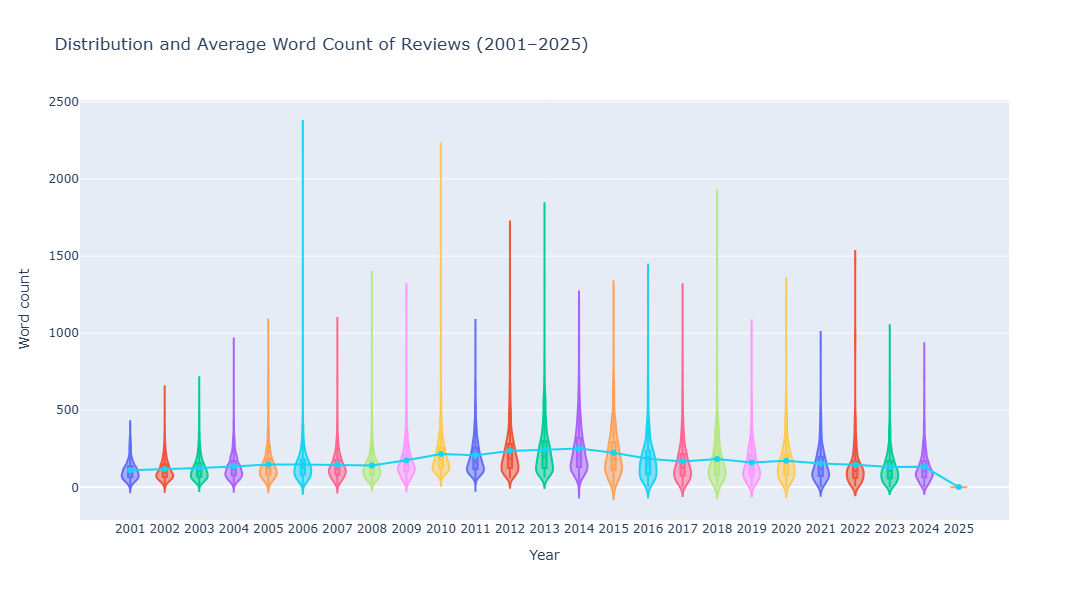

In [135]:
import plotly.graph_objects as go

# per-year means
avg_by_year = df.groupby("year", as_index=False)["word_count"].mean()

fig = go.Figure()

# violins (distribution) for each year
for y in sorted(df["year"].unique()):
    vals = df.loc[df["year"] == y, "word_count"]
    fig.add_trace(
        go.Violin(
            x=[str(y)] * len(vals),      
            y=vals,
            name=str(y),
            box_visible=True,           
            meanline_visible=False,
            points=False                 
        )
    )

# mean trend line overlay
fig.add_trace(
    go.Scatter(
        x=avg_by_year["year"].astype(str),
        y=avg_by_year["word_count"],
        mode="lines+markers",
        name="Mean word count"
    )
)

fig.update_layout(
    title="Distribution and Average Word Count of Reviews (2001–2025)",
    xaxis_title="Year",
    yaxis_title="Word count",
    violinmode="overlay",  
    showlegend=False,
    width=1200,
    height=600
)

fig.write_html('culpawordcount.html')
fig.show()

In [136]:
# reviews per year
print(df.groupby("year").size())

# unique word counts per year
print(df.groupby("year")["word_count"].nunique())

# preview data
print(df[["year", "word_count"]].head(20))

year
2001     518
2002    1605
2003    2380
2004    2523
2005    2511
2006    1997
2007    1397
2008    1031
2009    1558
2010    1477
2011    1423
2012    1027
2013    1069
2014     913
2015     663
2016     655
2017     789
2018     612
2019     513
2020     360
2021     581
2022     203
2023    1099
2024     913
2025      33
dtype: int64
year
2001    206
2002    305
2003    355
2004    375
2005    417
2006    377
2007    342
2008    291
2009    409
2010    391
2011    397
2012    383
2013    406
2014    414
2015    353
2016    328
2017    333
2018    320
2019    277
2020    231
2021    280
2022    147
2023    329
2024    306
2025      3
Name: word_count, dtype: int64
     year  word_count
510  2001         127
513  2001          32
514  2001          44
515  2001          25
516  2001          42
517  2001          57
518  2001         117
527  2001         121
528  2001         142
529  2001         137
530  2001          79
531  2001          48
532  2001         106
533  2001    

Index([2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012,
       2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024,
       2025],
      dtype='int32', name='year')
[ 518 1605 2380 2523 2511 1997 1397 1031 1558 1477 1423 1027 1069  913
  663  655  789  612  513  360  581  203 1099  913   33]


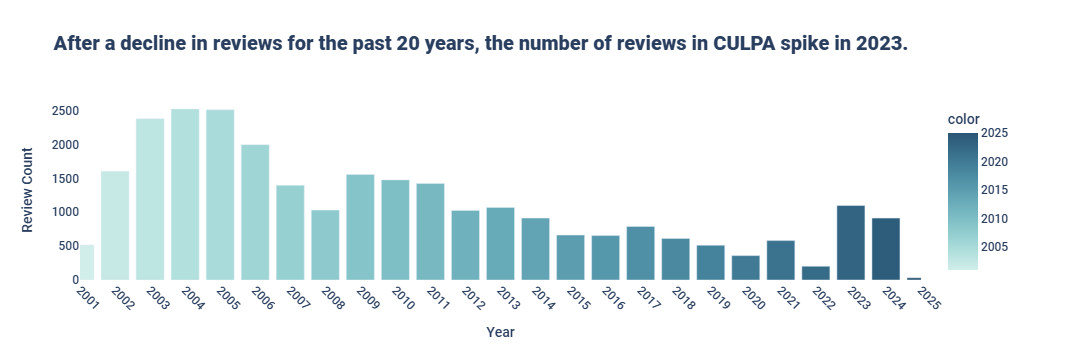

In [137]:
# plotting number of reviews over the years:

import plotly.express as px

review_counts = df.groupby('year').size()

print(review_counts.index)

print(review_counts.values)

fig = px.bar(x=review_counts.index, y=review_counts.values, labels={'x': 'Year', 'y': 'Review Count'}, color=review_counts.index, 
             color_continuous_scale=px.colors.sequential.Teal, title='<b>After a decline in reviews for the past 20 years, the number of reviews in CULPA spike in 2023.</b>')

# Add right margin so colorbar doesn't overlap content
fig.update_layout(
    margin=dict(r=150),  # increase if colorbar is still overlapping
    xaxis=dict(
        range=[df["year"].min(), 2025],
        dtick=1,          # show every year
        tickangle=45      # angle so years don't overlap each other
    )
)

fig.update_annotations(
    dict(
        x=2023,           
        y=1100,           
        ax=-200,          
        ay=-80,          
        text="Reviews increase after a steady decline over the years.",
        xanchor="right",  
    )
)

fig.update_layout(
    font=dict(family="Roboto", size=12),
    title_font=dict(family="Roboto", size=20),
    plot_bgcolor="white"
)

# creating html file
html_str = fig.to_html(
    include_plotlyjs="cdn",
    full_html=True,
    include_mathjax="cdn"
)

fig.update_xaxes(automargin=True)
# ensuring roboto font to match with spectator style guide
font_link = '<link href="https://fonts.googleapis.com/css2?family=Roboto:wght@300;400;700&display=swap" rel="stylesheet">'
html_str = html_str.replace("<head>", f"<head>\n{font_link}")

# manually opening a file and writing it
with open("culpa_review_count.html", "w") as f:
    f.write(html_str)

fig.show()

                            OLS Regression Results                            
Dep. Variable:         sentence_count   R-squared:                       0.004
Model:                            OLS   Adj. R-squared:                 -0.040
Method:                 Least Squares   F-statistic:                   0.08443
Date:                Sun, 26 Apr 2026   Prob (F-statistic):              0.774
Time:                        14:16:30   Log-Likelihood:                -58.729
No. Observations:                  25   AIC:                             121.5
Df Residuals:                      23   BIC:                             123.9
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         51.9041    147.559      0.352      0.7

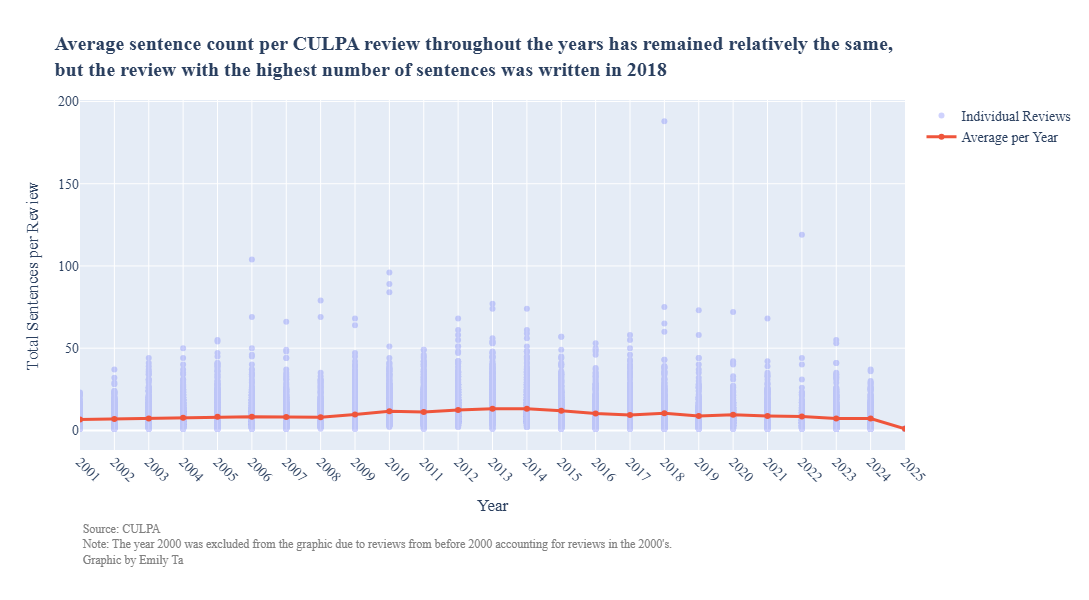

In [165]:
# counting average # of sentences per review, sliced per year
import re
from nltk.tokenize import sent_tokenize

df["C"] = df["C"].astype(str)

# count number of sentences per review
df["sentence_count"] = df["C"].apply(lambda x: len(sent_tokenize(x)))

# compute average sentence count per year
avg_per_year = df.groupby("year")["sentence_count"].mean().reset_index()

import plotly.graph_objects as go

fig = go.Figure()

# Scatterplot: all reviews
fig.add_trace(go.Scatter(
    x=df["year"],
    y=df["sentence_count"],
    mode="markers",
    name="Individual Reviews",
    opacity=0.3
))

# Line: yearly average
fig.add_trace(go.Scatter(
    x=avg_per_year["year"],
    y=avg_per_year["sentence_count"],
    mode="lines+markers",
    name="Average per Year",
    line=dict(width=3)
))

fig.update_layout(
    title="<b>Average sentence count per CULPA review throughout the years has remained relatively the same,<br>but the review with the highest number of sentences was written in 2018</b>",
    xaxis_title="Year",
    yaxis_title="Total Sentences per Review"
)

fig.add_annotation(      
    text="Source: CULPA<br>Note: The year 2000 was excluded from the graphic due to reviews from before 2000 accounting for reviews in the 2000's.<br>Graphic by Emily Ta",  
    xref="paper",
    yref="paper",
    x=0,          
    y=-0.2,      
    showarrow=False,
    align="left",
    xanchor="left",
    yanchor="top", 
    font=dict(size=12, color="gray")
)

# using OLS regression to see if relation between year & sentence count increases
import statsmodels.api as sm

X = sm.add_constant(avg_per_year["year"])
model = sm.OLS(avg_per_year["sentence_count"], X).fit()
print(model.summary())

fig.update_layout(
    font=dict(family="Roboto", size=14),
    title_font=dict(family="Roboto", size=20)
)

fig.update_layout(
    margin=dict(b=150),
    width=1200, 
    height=600
)

fig.update_layout(
    xaxis=dict(
        range=[df["year"].min(), 2025],
        dtick=1,         
        tickangle=45
    )
)

# creating html file
html_str = fig.to_html(
    include_plotlyjs="cdn",
    full_html=True,
    include_mathjax="cdn"
)

fig.update_xaxes(automargin=True)
# ensuring roboto font to match with spectator style guide
font_link = '<link href="https://fonts.googleapis.com/css2?family=Roboto:wght@300;400;700&display=swap" rel="stylesheet">'
html_str = html_str.replace("<head>", f"<head>\n{font_link}")

# manually opening a file and writing it
with open("sentence_count.html", "w") as f:
    f.write(html_str)

fig.show()

In [144]:
# installing hugging face dependencies

# import pyabsa 

# from pyabsa import AspectTermExtraction as ATE, AspectSentimentTripletExtraction as ASTE

# from pyabsa import AspectPolarityClassification as APC

#sentiment_classifier = APC.SentimentClassifier(
 #   checkpoint="multilingual", 
#)

#extractor = ATE.AspectExtractor(checkpoint="english")

#result = extractor.predict(
 #   text=[
  #      "The professor explains concepts clearly but grades very harshly.",
   #     "The course content was very relevant but the workload was overwhelming.",
    #    "Office hours were useless but the lecture slides were excellent."
    #],
    #print_result=True,
    #ignore_error=True
#)

# Print structured output
#for r in result:
 #   print(r) 

# creating another dataframe that only includes the specific years we want to analyze
# 2006, 2016, 2018, 2020, 2021, 2024, 2025 (or what we currently have now)

years = [2006, 2016, 2018, 2020, 2021, 2024, 2025]

df_filtered = df[df['year'].isin(years)]

df_filtered

from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np

# utilizing tf-idf to find naturally occuring keywords
keywords = {}

for year in years:
    
    year_df = df_filtered[df_filtered["year"] == year]
    other_df = df_filtered[df_filtered["year"] != year]

    # fit on ALL reviews so IDF is calculated globally
    tfidf = TfidfVectorizer(
        max_features=100, 
        stop_words="english",
        ngram_range=(1,2)  # captures phrases like "zoom class"
    )
    tfidf.fit(df_filtered["C"])

    # comparing the selected year with the reviews of the other years
    year_matrix = tfidf.transform(year_df["C"])
    other_matrix = tfidf.transform(other_df["C"])

    year_scores = np.asarray(year_matrix.mean(axis=0)).flatten()
    other_scores = np.asarray(other_matrix.mean(axis=0)).flatten()

    difference = year_scores - other_scores
    feature_names = tfidf.get_feature_names_out()

    top_words = sorted(zip(difference, feature_names), reverse=True)[:20]
    keywords[year] = [word for score, word in top_words]
    
    print(f"\nTop characteristic words for {year}:")
    for score, word in top_words:
        print(f"  {word}: {score:.4f}")




Top characteristic words for 2006:
  teacher: 0.0302
  book: 0.0233
  good: 0.0167
  ll: 0.0160
  reading: 0.0152
  papers: 0.0127
  nice: 0.0127
  class: 0.0102
  really: 0.0099
  interesting: 0.0095
  doesn: 0.0094
  little: 0.0093
  don: 0.0091
  problem: 0.0084
  easy: 0.0077
  writing: 0.0073
  work: 0.0073
  actually: 0.0067
  paper: 0.0063
  better: 0.0062

Top characteristic words for 2016:
  professor: 0.0145
  interesting: 0.0130
  material: 0.0128
  class: 0.0124
  readings: 0.0114
  make: 0.0102
  students: 0.0102
  way: 0.0098
  reading: 0.0097
  week: 0.0095
  paper: 0.0094
  read: 0.0085
  best: 0.0081
  hours: 0.0080
  time: 0.0078
  easy: 0.0069
  lecture: 0.0065
  questions: 0.0064
  learning: 0.0063
  taking: 0.0063

Top characteristic words for 2018:
  exams: 0.0191
  professor: 0.0187
  readings: 0.0127
  course: 0.0126
  don: 0.0119
  grade: 0.0112
  recommend: 0.0100
  hard: 0.0087
  feel: 0.0085
  super: 0.0083
  semester: 0.0082
  questions: 0.0082
  office: 0

In [145]:
# examining scores across all years

from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np

# fit on ALL reviews so IDF is calculated globally
tfidf = TfidfVectorizer(
    max_features=100, 
    stop_words="english",
    ngram_range=(1,2)     
)

tfidf.fit(df["C"].dropna())

#average score across all years
tfidf_matrix = tfidf.transform(df["C"].dropna())
scores = np.asarray(tfidf_matrix.mean(axis=0)).flatten() # mean scores of tfidf of the words we analyze
feature_names = tfidf.get_feature_names_out() # names of features

global_words = sorted(zip(scores, feature_names), reverse=True)[:20]

print(f"\nTop unique words:")
for score, word in global_words[:30]:
    print(f"  {word}: {score:.4f}")
    


Top unique words:
  class: 0.2027
  professor: 0.0889
  really: 0.0809
  students: 0.0707
  course: 0.0693
  just: 0.0586
  time: 0.0565
  good: 0.0563
  like: 0.0552
  lectures: 0.0550
  great: 0.0547
  material: 0.0521
  don: 0.0510
  interesting: 0.0505
  lot: 0.0478
  teacher: 0.0417
  questions: 0.0415
  semester: 0.0412
  work: 0.0409
  know: 0.0405


In [146]:
# unigrams with max_df filter
tfidf_uni = TfidfVectorizer(
    max_features=50,
    stop_words="english",
    ngram_range=(1,1),
    min_df=0.01,
    max_df=0.5
)

# bigrams only
tfidf_bi = TfidfVectorizer(
    max_features=50,
    stop_words="english",
    ngram_range=(2,2),
    min_df=0.005,
    max_df=0.5
)

reviews = df["C"].dropna().reset_index(drop=True)

tfidf_uni.fit(reviews)
tfidf_bi.fit(reviews)

matrix_uni = tfidf_uni.transform(reviews)
matrix_bi = tfidf_bi.transform(reviews)

mean_uni = np.asarray(matrix_uni.mean(axis=0)).flatten()
mean_bi = np.asarray(matrix_bi.mean(axis=0)).flatten()

print("Top words:")
for score, word in sorted(zip(mean_uni, tfidf_uni.get_feature_names_out()), reverse=True)[:20]:
    print(f"  {word}: {score:.4f}")

print("\nTop two-word phrases:")
for score, word in sorted(zip(mean_bi, tfidf_bi.get_feature_names_out()), reverse=True)[:20]:
    print(f"  {word}: {score:.4f}")

Top words:
  professor: 0.1176
  really: 0.1065
  students: 0.0932
  course: 0.0902
  just: 0.0782
  time: 0.0755
  good: 0.0744
  like: 0.0735
  lectures: 0.0728
  great: 0.0717
  material: 0.0687
  don: 0.0673
  interesting: 0.0659
  lot: 0.0626
  questions: 0.0552
  semester: 0.0549
  teacher: 0.0547
  make: 0.0539
  work: 0.0539
  know: 0.0536

Top two-word phrases:
  office hours: 0.0685
  midterm final: 0.0311
  problem sets: 0.0278
  taking class: 0.0274
  make sure: 0.0265
  class really: 0.0249
  highly recommend: 0.0248
  recommend class: 0.0231
  nice guy: 0.0230
  don know: 0.0226
  feel like: 0.0220
  ve taken: 0.0211
  lit hum: 0.0210
  outside class: 0.0207
  class discussion: 0.0200
  class professor: 0.0194
  great professor: 0.0192
  end semester: 0.0192
  class just: 0.0192
  took class: 0.0189


In [148]:
import json
import pandas as pd
import nltk
!pip install vaderSentiment
import sys
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

nltk.download('punkt')
nltk.download('punkt_tab')

analyzer = SentimentIntensityAnalyzer()

keyword_list = [
    "problem sets", "workload", "homework", "readings", "work", "pset",
    "problem set", "assignments", "assignment", "exams", "midterm", "final",
    "grade", "grading", "office hours", "class discussion", "lectures", "lecture",
    "material", "lit hum", "time", "questions", "recommend", "commitment", "attendance", "participation",
    "quiz", "quizzes", "core curriculum", "papers", "paper", "essay", "curve"
]

def analyze_review(text, keywords):
    results = []
    try:
        sentences = nltk.sent_tokenize(text)
    except:
        sentences = text.split(". ")
    
    for sent in sentences:
        sent_lower = sent.lower()
        for kw in keywords:
            if kw in sent_lower:
                score = analyzer.polarity_scores(sent)
                results.append({
                    "keyword":   kw,
                    "sentence":  sent,
                    "positive":  score["pos"],
                    "negative":  score["neg"],
                    "neutral":   score["neu"],
                    "compound":  score["compound"]  # -1 (most negative) to +1 (most positive)
                })
    return results

# Dataframe preparation
df_clean = df.dropna(subset=["C"]).copy() # dropping missing reviews
df_clean = df_clean.drop_duplicates(subset=["C"]).reset_index(drop=True)

all_results = []
for _, row in df_clean.iterrows():
    matches = analyze_review(row["C"], keyword_list)
    for m in matches:
        m["C"] = row["C"]
        all_results.append(m)

vader_df = pd.DataFrame(all_results)
print(f"Total keyword-sentence matches: {len(vader_df)}")
print(vader_df.head(10))

# Aggregate by the keywords list developed
summary = vader_df.groupby("keyword").agg(
    mentions    = ("compound", "count"),
    avg_compound= ("compound", "mean"),
    avg_positive= ("positive", "mean"),
    avg_negative= ("negative", "mean"),
    pct_positive= ("compound", lambda x: (x > 0.05).sum() / len(x)),
    pct_negative= ("compound", lambda x: (x < -0.05).sum() / len(x)),
    pct_neutral = ("compound", lambda x: (x.between(-0.05, 0.05)).sum() / len(x))
).reset_index()

print(summary.sort_values("mentions", ascending=False))

C:\Users\emiik\anaconda3\envs\absa_env\lib\threading.py:957: ResourceWarning: unclosed file <_io.BufferedWriter name=5>
  del self._target, self._args, self._kwargs
C:\Users\emiik\anaconda3\envs\absa_env\lib\threading.py:957: ResourceWarning: unclosed file <_io.BufferedReader name=6>
  del self._target, self._args, self._kwargs
C:\Users\emiik\anaconda3\envs\absa_env\lib\threading.py:957: ResourceWarning: unclosed file <_io.BufferedReader name=7>
  del self._target, self._args, self._kwargs
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\emiik\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\emiik\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


Total keyword-sentence matches: 163846
      keyword                                           sentence  positive  \
0     lecture  Heise, although quite a nice person, is far fr...     0.359   
1    lectures  Her lectures don't draw too much out of the re...     0.000   
2     lecture  Her lectures don't draw too much out of the re...     0.000   
3     lecture  Even with a huge lecture class, she tries to g...     0.133   
4  attendance  Even with a huge lecture class, she tries to g...     0.133   
5    readings  The readings she assigned were fantastic, but ...     0.085   
6     grading  The grading is surprisingly easy, but sitting ...     0.244   
7    material  Also, there were some moments when she was sim...     0.000   
8        work  She is a fair professor and she does follow th...     0.153   
9    lectures  Unfortunately one of the only permenent lectur...     0.000   

   negative  neutral  compound  \
0     0.000    0.641    0.8062   
1     0.261    0.739   -0.6486   


In [153]:
all_results = []
for _, row in df_clean.iterrows():
    matches = analyze_review(row["C"], keyword_list)
    for m in matches:
        all_results.append(m)  #matches in the results

vader_df = pd.DataFrame(all_results)

# create a summary dataframe
summary = vader_df.groupby("keyword").agg(
    mentions    = ("compound", "count"),
    avg_compound= ("compound", "mean"),
    avg_positive= ("positive", "mean"),
    avg_negative= ("negative", "mean"),
    pct_positive= ("compound", lambda x: (x > 0.05).sum() / len(x)),
    pct_negative= ("compound", lambda x: (x < -0.05).sum() / len(x)),
).reset_index()

print(summary)


             keyword  mentions  avg_compound  avg_positive  avg_negative  \
0         assignment      3763      0.139824      0.098768      0.051678   
1        assignments      2897      0.160076      0.106173      0.051738   
2         attendance       773      0.095646      0.085743      0.051666   
3   class discussion      1307      0.312247      0.152258      0.037883   
4         commitment       114      0.413487      0.212939      0.054175   
5    core curriculum        48      0.250652      0.136229      0.047271   
6              curve      1780      0.160112      0.124724      0.063365   
7              essay      3063      0.191709      0.099312      0.041736   
8              exams      4910      0.098928      0.097122      0.066081   
9              final      6990      0.120090      0.085691      0.048398   
10             grade     10351      0.161341      0.123374      0.065030   
11           grading      3153      0.137125      0.132819      0.078668   
12          

In [157]:
# Checking out grade-related keywords & teaching-related keywords and their compound scores

grade_keywords = ["grade", "grading", "curve", "exams", "midterm", 
                  "final", "homework", "problem set", "problem sets", 
                  "pset", "quiz", "quizzes", "assignment", "assignments"]

teaching_keywords = ["lecture", "lectures", "office hours", "material",
                     "class discussion", "participation", "readings"]

grade_df    = vader_df[vader_df["keyword"].isin(grade_keywords)]
teaching_df = vader_df[vader_df["keyword"].isin(teaching_keywords)]

print("Grade-related average compound:   ", grade_df["compound"].mean().round(3))
print("Teaching-related average compound:", teaching_df["compound"].mean().round(3))

Grade-related average compound:    0.099
Teaching-related average compound: 0.231


In [22]:
# import pyabsa 

# from pyabsa import AspectTermExtraction as ATE, AspectSentimentTripletExtraction as ASTE

# from pyabsa import AspectPolarityClassification as APC

#sentiment_classifier = APC.SentimentClassifier(
 #   checkpoint="multilingual", 
#)

#extractor = ATE.AspectExtractor(checkpoint="english")

#result = extractor.predict(
 #   text=[
  #      "The professor explains concepts clearly but grades very harshly.",
   #     "The course content was very relevant but the workload was overwhelming.",
    #    "Office hours were useless but the lecture slides were excellent."
    #],
    #print_result=True,
    #ignore_error=True
#)

# Print structured output
#for r in result:
 #   print(r) 

In [23]:
# this block should be modified based on the github repo we are trying to access
import subprocess
import os
user = "m3redithw"
repo = "data-science-visualizations"
src_dir = "WordClouds"
pyfile = "prepare.py"

# f-string to get the url
url = f"https://raw.githubusercontent.com/{user}/{repo}/main/{src_dir}/{pyfile}"

# --no-cache ensures the latest option to be downloaded
# --backups=1 saves any previous version
#!wget --no-cache --backups=1 {url}
import wget
wget.download(url)

ModuleNotFoundError: No module named 'wget'